# Plant detection from RGB UAV imagery

This notebook demonstrates the plant detection pipeline implemented in
`OpenCropPhenotyping`.

The pipeline detects theoretical planting positions within crop rows
and identifies potential missing plants using the fraction of vegetation
pixels detected around each expected position.

The workflow is based on RGB UAV imagery and includes:

1. RGB image preprocessing;
2. Excess Green (ExG) computation;
3. vegetation segmentation;
4. crop-row orientation estimation;
5. image rotation;
6. crop-row extraction;
7. theoretical plant-position estimation;
8. vegetation-based plant detection.

## Dataset

The demonstration uses an annotated UAV image from the toy segmentation
dataset included with the project.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from opencropphenotyping.segmentation import (
    detect_plants,
)
from opencropphenotyping.visualization import (
    plot_crop_row_profiles,
    plot_exg_with_detected_plants,
    plot_rgb_with_annotations,
    plot_rgb_with_annotations_and_detected_plants,
    plot_rgb_with_detected_plants,
    plot_row_masks,
)

from opencropphenotyping.evaluation import (
    prepare_rotated_annotation_points,
    evaluate_plant_detection,
)

from opencropphenotyping.io import write_png, write_figure

In [2]:
project_root = Path.cwd().parent

dataset_dir = (
    project_root
    / "data"
    / "raw"
    / "toy_datasets"
    / "toy_segmentation"
)

image_path = dataset_dir / "103_DSC01167.png"

geotiff_path = (
    dataset_dir
    / "georeferenced"
    / "103_DSC01167.tif"
)

geopackage_path = (
    dataset_dir
    / "geopackages"
    / "103_DSC01167.gpkg"
)

json_paths = list(dataset_dir.glob("*.json"))
output_figure_path = (
    project_root
    / "docs"
    / "images"
)

Image shape: (987, 2371, 3)


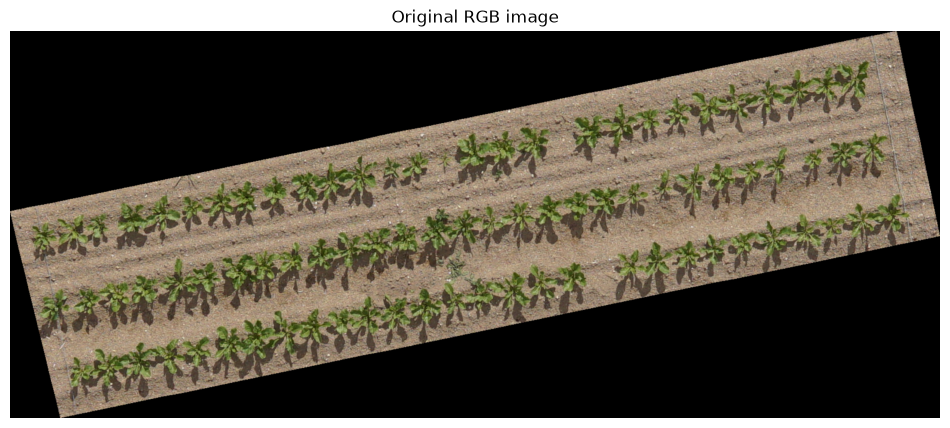

In [3]:
image = np.array(Image.open(image_path))

print(f"Image shape: {image.shape}")

plt.figure(figsize=(12, 8))
plt.imshow(image)
plt.axis("off")
plt.title("Original RGB image")
plt.show()

write_png(
    image=image,
    output_path=output_figure_path / "rgb.png",
    )

In [4]:
(
    best_angle,
    rotated_img,
    rotated_exg,
    vegetation_mask,
    row_profile,
    peaks,
    boundaries,
    row_images,
    row_masks,
    row_detections,
    plants_df,
) = detect_plants(
    image_path=image_path,
    geotiff_path=geotiff_path,
    geopackage_path=geopackage_path,
    vegetation_fraction_threshold=0.04,
    export_all=True,
)


Processing: 103_DSC01167
Rows detected: 3 | Expected rows: 3 | Planting positions: 87 | Plants detected: 86


In [5]:
print(f"Estimated rotation angle: {best_angle:.2f}°")
print(f"Detected crop rows: {len(peaks)}")
print(f"Expected crop rows: {len(boundaries) - 1}")
print(f"Expected plants: {len(plants_df)}")

Estimated rotation angle: -11.00°
Detected crop rows: 3
Expected crop rows: 3
Expected plants: 87


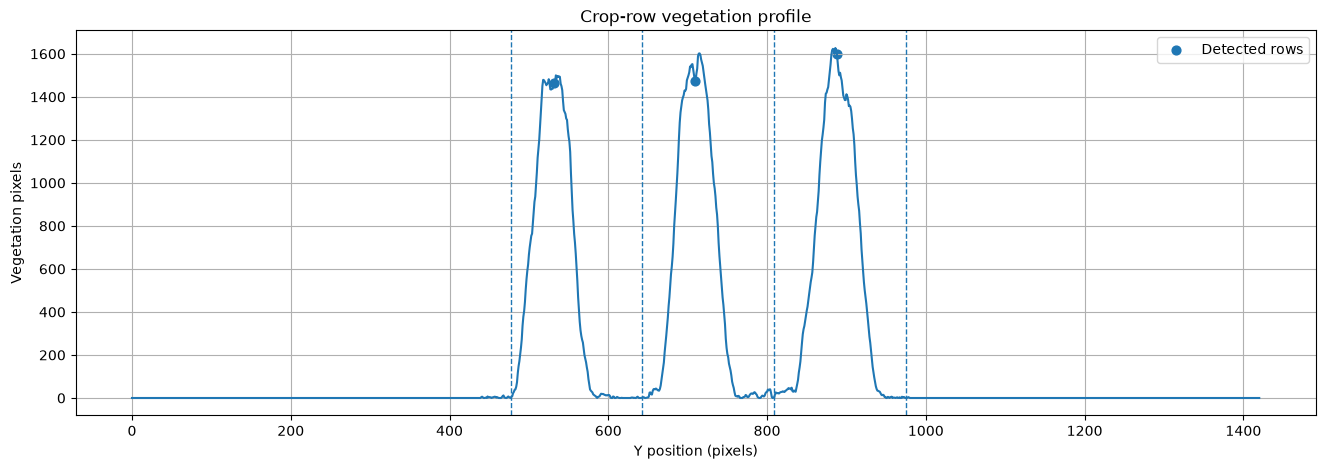

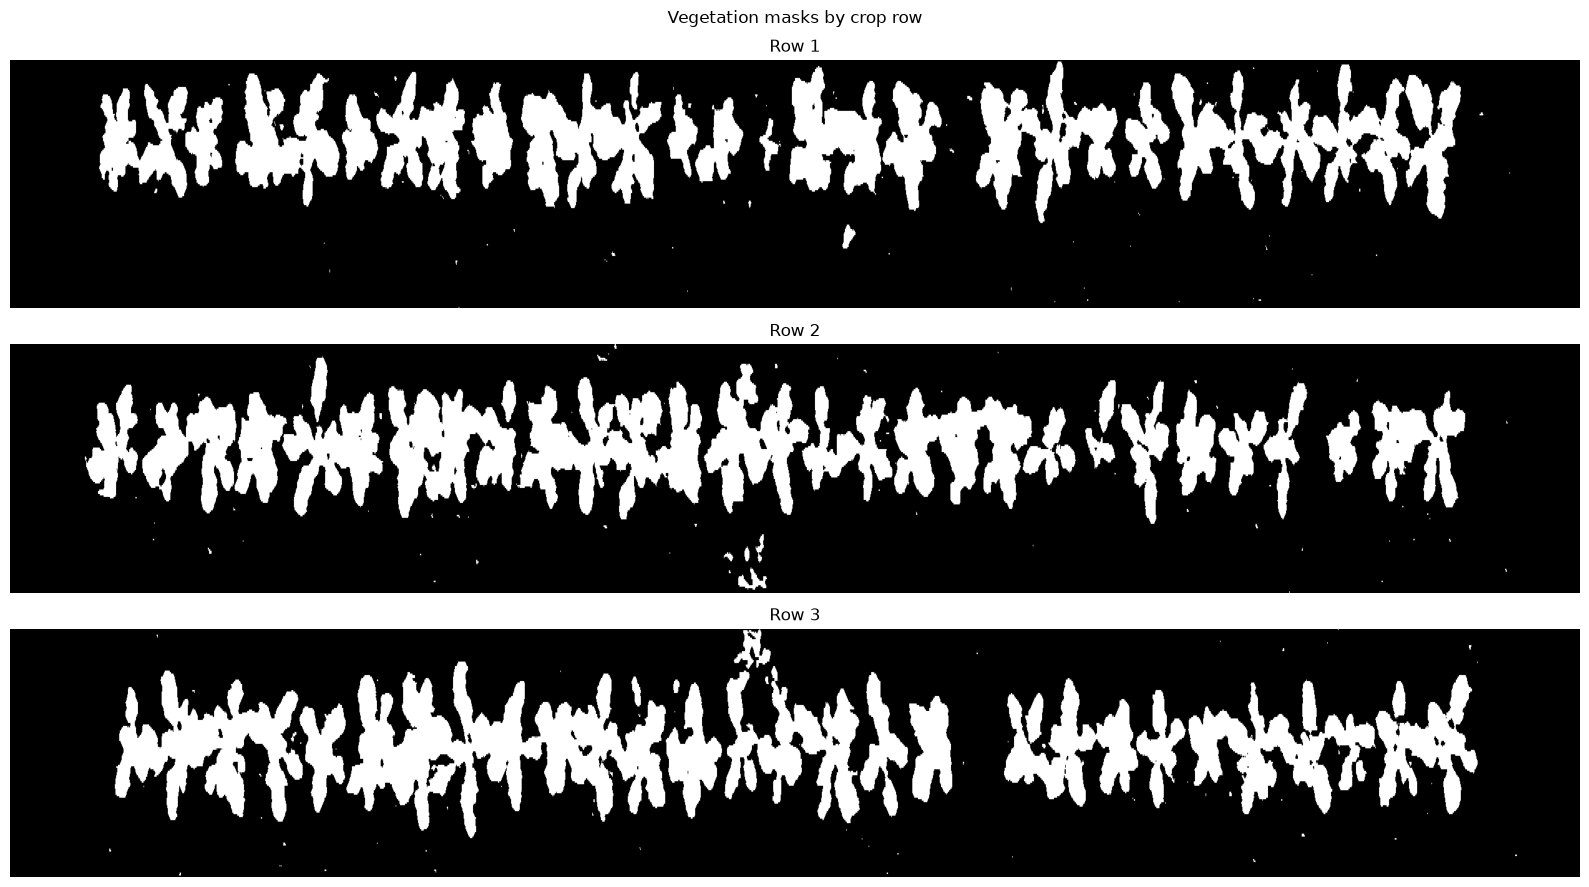

In [7]:
# Visualize the crop row profile with detected rows and the row masks

fig = plot_crop_row_profiles(row_profile=row_profile, peaks=peaks, boundaries=boundaries)
plt.show()
write_figure(
    fig=fig,
    output_path=output_figure_path / "crop_row_profile.png",
    )
plt.close(fig)

fig = plot_row_masks(row_masks=row_masks)
plt.show()
write_figure(
    fig=fig,
    output_path=output_figure_path / "row masks.png",
    )
plt.close(fig)

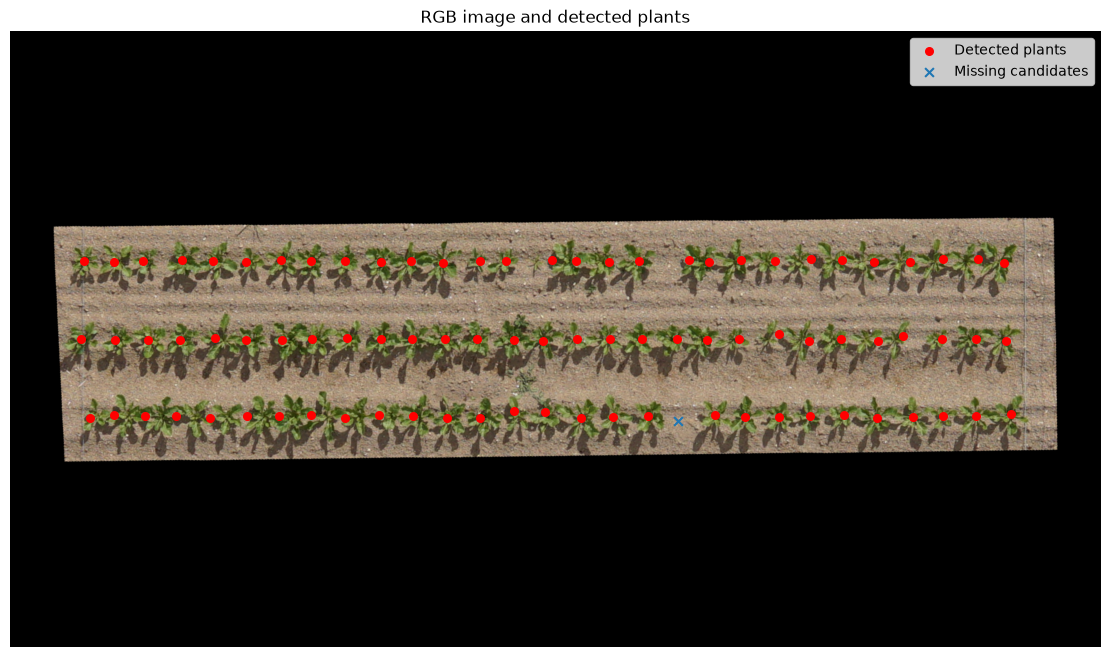

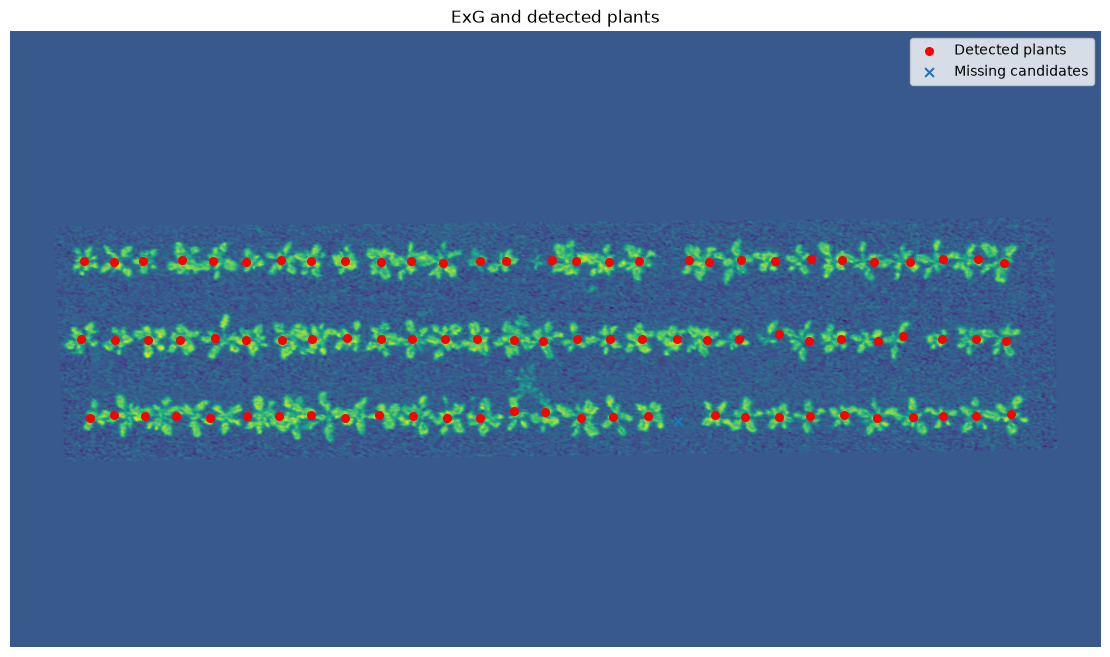

In [8]:
# Visualize detected and missing plants

fig = plot_rgb_with_detected_plants(image=rotated_img, plant_df=plants_df)
plt.show()
write_figure(
    fig=fig,
    output_path=output_figure_path / "rgb_detection.png",
    )
plt.close(fig)

fig = plot_exg_with_detected_plants(exg=rotated_exg, plant_df=plants_df)
plt.show()
write_figure(
    fig=fig,
    output_path=output_figure_path / "exg_detection.png",
    )
plt.close(fig)

In [10]:
# Load COCO annotations

annotation_points_rotated = prepare_rotated_annotation_points(
    json_paths=json_paths,
    image_path=image_path,
    best_angle=best_angle,
    rotated_shape=rotated_img.shape[:2],
)

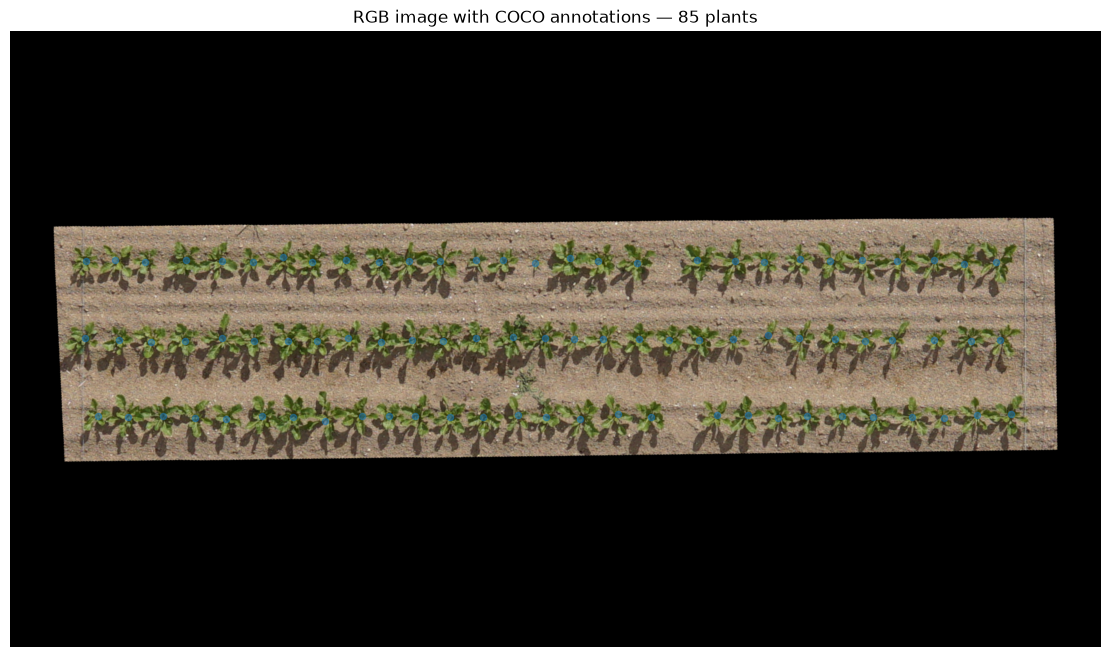

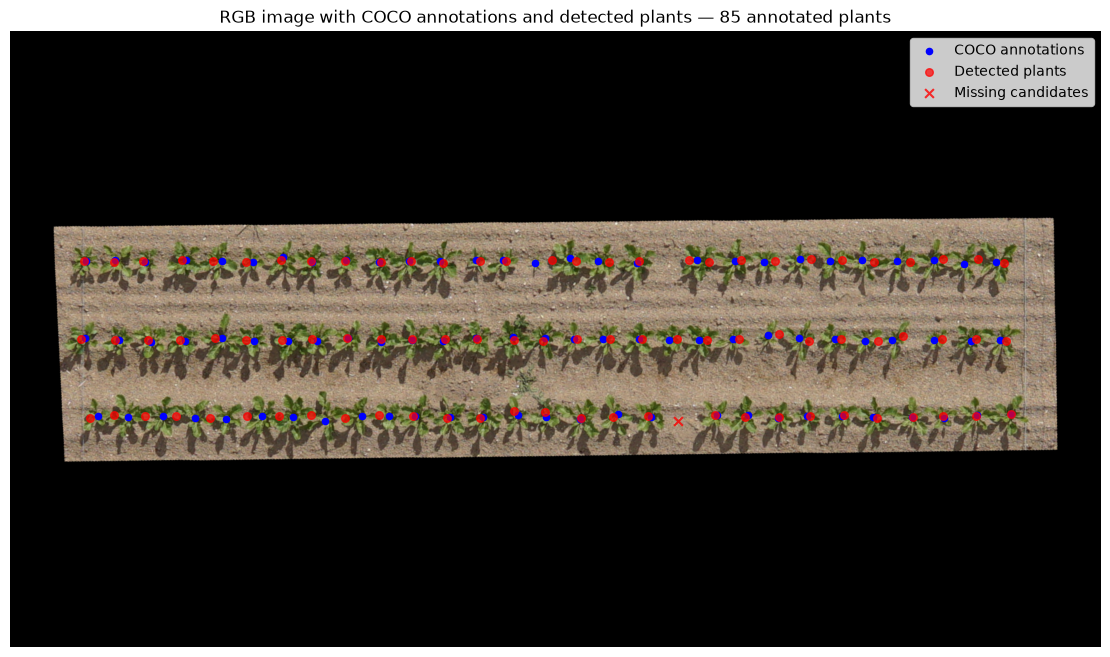

In [11]:
# Visualise COCO annotations and compare with detection

fig = plot_rgb_with_annotations(
    image=rotated_img,
    annotations=annotation_points_rotated
)
plt.show()
write_figure(
    fig=fig,
    output_path=output_figure_path / "rgb_annotations.png",
    )
plt.close(fig)

fig = plot_rgb_with_annotations_and_detected_plants(
    image=rotated_img,
    annotations=annotation_points_rotated,
    plant_df=plants_df
)
plt.show()
write_figure(
    fig=fig,
    output_path=output_figure_path / "rgb_detection_annotations.png",
    )
plt.close(fig)

In [12]:
# Compute metrics

evaluate_plant_detection(
    plants_df=plants_df,
    annotation_points=annotation_points_rotated,
    boundaries=boundaries
)

(    plant_position  expected_x  row_profile_pixels   centroid_x  centroid_y  \
 0                1         156                2371   169.961620  529.564741   
 1                2         233                2798   239.047891  531.304146   
 2                3         310                2525   306.306139  530.180990   
 3                4         387                3270   397.418960  527.439450   
 4                5         464                3515   468.349929  528.947653   
 ..             ...         ...                 ...          ...         ...   
 82              25        2002                3308  1998.685913  892.018138   
 83              26        2079                3157  2082.110865  890.333861   
 84              27        2156                1809  2152.222775  887.295191   
 85              28        2233                3181  2227.429739  888.369381   
 86              29        2310                3441  2307.798896  883.941296   
 
        offset  abs_offset  x_start  x

## Summary

This demonstration shows a rule-based plant detection workflow based on
RGB UAV imagery.

The method:

- estimates crop-row orientation from vegetation patterns;
- rotates the image to align crop rows;
- defines theoretical planting positions from plot geometry;
- searches for vegetation around each expected position;
- computes the vegetation fraction within each search window;
- flags positions with insufficient vegetation as potential missing plants.

The resulting detections can be compared with manual COCO annotations
using precision, recall and F1-score.

The current approach is intentionally based on interpretable image
processing methods. Machine-learning-based approaches are planned for
future versions of OpenCropPhenotyping.